# 02 — Hedonic Price Modeling (v2)

**Goal**: Estimate the fair market value of a home from physical attributes,
neighbourhood-level Census socioeconomics, and spatial coordinates.

### Statistical methodology
| Step | Detail |
|------|--------|
| **Train / test split** | 80 / 20 random split, held-out test set touched only once |
| **Feature selection** | Property attributes + Census ACS rates + spatial coordinates + seasonality |
| **Cross-validation** | 5-fold CV on the *training* set for model comparison |
| **Hyperparameter tuning** | Optuna TPE search (120 trials, expanded space incl. `num_leaves`, `min_split_gain`) |
| **Prediction intervals** | Native LightGBM quantile regression at p=0.10 and p=0.90 — no normality assumption |
| **Final evaluation** | Best model re-fit on full dataset; CV predictions used for residual diagnostics |
| **Reproducibility** | `SEED = 51` everywhere |

### Key feature engineering additions (v2)
| Feature | Rationale |
|---------|-----------|
| `BEDS_clean`, `beds_sq` | Raw bed count was missing from v1; quadratic term captures diminishing-returns |
| `lat_c`, `lon_c` + interactions | Centred lat/lon with quadratic and cross terms — captures spatial price gradients across Del+Mont Counties (−$1,652 MAE improvement alone) |
| `lot_capped` | 99th-percentile winsorisation of LOT_SIZE removes data-entry errors (max was 115M sqft) |
| `sin_month`, `cos_month`, `is_spring` | Cyclical encoding of sold month captures seasonality ($30k peak-to-trough) |
| `wealth_edu_idx` | Composite percentile rank of income + education — single-index neighbourhood quality signal |
| `bath_per_sqft`, `age_historic_x` | Density of bathrooms; age × historic flag captures pre-war premium vs. deferred-maintenance risk |

### Key assumptions
1. Sold prices over the trailing 12 months represent current market conditions.
2. Census ACS 5-year ZCTA estimates are stable neighbourhood quality proxies.
3. Additive hedonic decomposition is reasonable for this suburban segment but may under-weight hyper-local school-catchment effects.
4. `pct_white` excluded (Fair Housing Act).
5. Filtered model restricts to SFR, Delaware + Montgomery Counties, $300k–$750k — the target segment.

**Inputs**: `data/redfin_with_census.csv`  
**Outputs**: `models/hedonic_model_filtered.joblib`, `models/hedonic_model.joblib`, `data/model_results_filtered.csv`, `data/model_results.csv`

In [1]:
# ---------------------------------------------------------------------------
# Imports & global config
# ---------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
import os
import joblib
import warnings
import logging

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor,
    StackingRegressor,
)
from sklearn.model_selection import (
    cross_val_score,
    cross_val_predict,
    KFold,
    train_test_split,
)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMRegressor
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
log = logging.getLogger(__name__)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

# ── Paths ────────────────────────────────────────────────────────────────────
JOINED_CSV           = "data/redfin_with_census.csv"
MODEL_FILE           = "models/hedonic_model.joblib"
FILTERED_MODEL_FILE  = "models/hedonic_model_filtered.joblib"
RESULTS_CSV          = "data/model_results.csv"
FILTERED_RESULTS_CSV = "data/model_results_filtered.csv"

os.makedirs("models", exist_ok=True)
os.makedirs("data", exist_ok=True)
os.makedirs("plots", exist_ok=True)

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 51
np.random.seed(SEED)

print(f"Seed: {SEED}")

Seed: 51


In [2]:
# ---------------------------------------------------------------------------
# Load data & feature engineering (v3)
# ---------------------------------------------------------------------------
df = pd.read_csv(JOINED_CSV, low_memory=False)
df = df.loc[:, ~df.columns.duplicated()]
log.info(f'Loaded {len(df):,} rows, {df.shape[1]} columns')

TARGET     = 'PRICE'
LOG_TARGET = 'LOG_PRICE'   # v3: train on log(price) to stabilise heteroscedasticity
BASE_YEAR  = 2026

if 'STATUS' in df.columns:
    before = len(df)
    df = df[df['STATUS'] == 'Sold'].copy()
    log.info(f'Filtered to sold only: {len(df):,} rows')

df = df[df['SQUARE_FEET'].fillna(0) > 0].copy()
log.info(f'After sqft>0 filter: {len(df):,} rows')

# Core property features
df['home_age']       = BASE_YEAR - df['YEAR_BUILT']
df['bath_bed_ratio'] = df['BATHS'] / df['BEDS'].replace(0, np.nan)
df['sqft_per_bed']   = df['SQUARE_FEET'] / df['BEDS'].replace(0, np.nan)
df['log_sqft']       = np.log1p(df['SQUARE_FEET'])
df['log_home_age']   = np.log1p(df['home_age'])
df['is_historic']    = (df['YEAR_BUILT'] < 1940).astype(int)
df['age_historic_x'] = df['home_age'] * df['is_historic']
df['BEDS_clean']     = df['BEDS'].clip(1, 7)
df['beds_sq']        = df['BEDS_clean'] ** 2
df['bath_per_sqft']  = df['BATHS'] / df['SQUARE_FEET'].clip(lower=1)

# Lot size winsorisation
# v3: LOT_99 computed on full target segment (no $750k price cap).
LOT_99 = df.loc[
    df['COUNTY'].isin(['Delaware County', 'Montgomery County']) &
    df['PROPERTY_TYPE'].isin(['Single Family Residential']) &
    df['PRICE'].between(300_000, 1_250_000),
    'LOT_SIZE'
].quantile(0.99)
df['lot_capped']          = df['LOT_SIZE'].clip(upper=LOT_99)
df['log_lot_capped']      = np.log1p(df['lot_capped'])
df['sqft_per_lot_capped'] = df['SQUARE_FEET'] / df['lot_capped'].clip(lower=1)

# Temporal features
df['SOLD_DATE']         = pd.to_datetime(df['SOLD_DATE'], errors='coerce')
BASE_DATE               = pd.Timestamp('2024-01-01')
df['months_since_base'] = ((df['SOLD_DATE'] - BASE_DATE).dt.days / 30.44).clip(lower=0)
df['month']             = df['SOLD_DATE'].dt.month.fillna(6).astype(int)
df['sin_month']         = np.sin(2 * np.pi * df['month'] / 12)
df['cos_month']         = np.cos(2 * np.pi * df['month'] / 12)
df['is_spring']         = df['month'].isin([3, 4, 5, 6]).astype(int)

# Spatial features
LAT_MEAN    = df['LATITUDE'].mean()
LON_MEAN    = df['LONGITUDE'].mean()
df['lat_c']     = df['LATITUDE']  - LAT_MEAN
df['lon_c']     = df['LONGITUDE'] - LON_MEAN
df['lat_sq']    = df['lat_c'] ** 2
df['lon_sq']    = df['lon_c'] ** 2
df['lat_lon_x'] = df['lat_c'] * df['lon_c']

# Census composites
df['income_sqft_idx'] = df['median_household_income'] / df['SQUARE_FEET'].replace(0, np.nan)
df['wealth_edu_idx']  = (
    df['median_household_income'].rank(pct=True) +
    df['pct_bachelors_plus'].rank(pct=True)
) / 2
df['commute_sq'] = df['mean_commute_time'] ** 2

# Log-price target (v3)
# Training on log(price) stabilises multiplicative heteroscedasticity.
# Spearman(|resid|, price) = 0.207 in v2 — highly significant; log transform
# removes this dependency so interval width scales with price level.
# Quantile PI coverage improves from 51% ($700k+) and 72% ($300-400k) toward 80%.
df[LOG_TARGET] = np.log(df[TARGET])

META_COLS = ['ADDRESS', 'CITY', 'zip', 'SOLD_DATE', 'LATITUDE', 'LONGITUDE']

PROPERTY_FEATURES = [
    'BEDS_clean', 'beds_sq', 'BATHS', 'SQUARE_FEET', 'log_sqft',
    'lot_capped', 'log_lot_capped', 'sqft_per_lot_capped',
    'home_age', 'log_home_age', 'is_historic', 'age_historic_x',
    'bath_bed_ratio', 'sqft_per_bed', 'bath_per_sqft',
    'months_since_base', 'sin_month', 'cos_month', 'is_spring',
]

CENSUS_FEATURES = [
    'median_household_income', 'median_home_value', 'median_gross_rent',
    'population', 'median_year_built_neighborhood', 'mean_commute_time',
    'vacancy_rate', 'pct_bachelors_plus', 'poverty_rate', 'homeownership_rate',
    'income_sqft_idx', 'wealth_edu_idx', 'commute_sq',
]

SPATIAL_FEATURES = ['lat_c', 'lon_c', 'lat_sq', 'lon_sq', 'lat_lon_x']

CATEGORICAL_FULL     = ['PROPERTY_TYPE', 'COUNTY']
CATEGORICAL_FILTERED = ['PROPERTY_TYPE']


def build_model_df(source_df, categorical_features, include_spatial=False):
    spatial = SPATIAL_FEATURES if include_spatial else []
    all_feats   = PROPERTY_FEATURES + CENSUS_FEATURES + spatial + categorical_features
    cols_needed = ([TARGET, LOG_TARGET] + all_feats
                   + [c for c in META_COLS if c in source_df.columns])
    cols_present = [c for c in cols_needed if c in source_df.columns]
    mdf = source_df[cols_present].copy()
    mdf = pd.get_dummies(mdf, columns=categorical_features, drop_first=True)
    mdf = mdf.dropna(subset=[TARGET])
    feat_cols = [c for c in mdf.columns if c not in [TARGET, LOG_TARGET] + META_COLS]
    for col in feat_cols:
        if mdf[col].isna().any():
            mdf[col] = mdf[col].fillna(mdf[col].median())
    return mdf, feat_cols


# Full dataset
model_df, feature_cols = build_model_df(df, CATEGORICAL_FULL, include_spatial=False)
log.info(f'Full modelling set: {model_df.shape[0]:,} x {len(feature_cols)} features')

# Filtered dataset
# v3 key change: FILTER_PRICE_MAX raised $750k -> $1,250,000.
# Prior $750k cap caused systematic underprediction of luxury homes:
#   median residual for $675k+ homes was +$63k (model never saw higher prices).
# 1,276 additional observations added; data supports up to $1.2M in this segment.
FILTER_COUNTIES  = ['Delaware County', 'Montgomery County']
FILTER_TYPES     = ['Single Family Residential']
FILTER_PRICE_MIN = 300_000
FILTER_PRICE_MAX = 1_250_000

df_filtered = df[
    df['COUNTY'].isin(FILTER_COUNTIES)
    & df['PROPERTY_TYPE'].isin(FILTER_TYPES)
    & df['PRICE'].between(FILTER_PRICE_MIN, FILTER_PRICE_MAX)
].copy()

log.info(f'Filtered segment: {len(df_filtered):,} rows ({len(df_filtered)/len(df)*100:.1f}%)')

model_df_f, feature_cols_f = build_model_df(
    df_filtered, CATEGORICAL_FILTERED, include_spatial=True
)
log.info(f'Filtered modelling set: {model_df_f.shape[0]:,} x {len(feature_cols_f)} features')

print(f'Full:     {model_df.shape[0]:,} rows, {len(feature_cols)} features')
print(f'Filtered: {model_df_f.shape[0]:,} rows, {len(feature_cols_f)} features')
print(f'  Price range: ${model_df_f[TARGET].min():,.0f} - ${model_df_f[TARGET].max():,.0f}')
print(f'LOT_99: {LOT_99:,.0f} sqft')
print(f'Spatial centroids - lat: {LAT_MEAN:.4f}, lon: {LON_MEAN:.4f}')


2026-04-09 18:52:24,377 INFO Loaded 23,754 rows, 39 columns
2026-04-09 18:52:24,384 INFO Filtered to sold only: 23,754 rows
2026-04-09 18:52:24,391 INFO After sqft>0 filter: 23,448 rows
2026-04-09 18:52:24,451 INFO Full modelling set: 23,448 x 38 features
2026-04-09 18:52:24,499 INFO Filtered segment: 6,345 rows (27.1%)
2026-04-09 18:52:24,535 INFO Filtered modelling set: 6,345 x 37 features


Full:     23,448 rows, 38 features
Filtered: 6,345 rows, 37 features
  Price range: $300,000 - $1,200,000
LOT_99: 156,210 sqft
Spatial centroids - lat: 40.1007, lon: -75.3333


In [3]:
# ---------------------------------------------------------------------------
# Train / Test split - 80/20, stratified by county
# ---------------------------------------------------------------------------

# Full dataset
X_full = model_df[feature_cols]
y_full = model_df[TARGET]

strat_col = next((c for c in model_df.columns if c.startswith('COUNTY_')), None)
strat = model_df[strat_col] if strat_col else None

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.20, random_state=SEED, stratify=strat,
)
log.info(f'Full - train: {len(X_train):,}  test: {len(X_test):,}')

# Filtered dataset
X_full_f = model_df_f[feature_cols_f]
y_full_f = model_df_f[TARGET]

# v3: log-price targets for the filtered model
# These are used for Optuna tuning and final model training.
# All predictions are exponentiated back to dollar values at evaluation/inference time.
y_full_f_log = model_df_f[LOG_TARGET]

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_full_f, y_full_f, test_size=0.20, random_state=SEED,
)

# Matching index split for log targets
train_idx = y_train_f.index
test_idx  = y_test_f.index
y_train_f_log = y_full_f_log.loc[train_idx]
y_test_f_log  = y_full_f_log.loc[test_idx]

log.info(f'Filtered - train: {len(X_train_f):,}  test: {len(X_test_f):,}')
print('Splits created.  Test sets are held out until final evaluation.')
print(f'Filtered log-price range: {y_full_f_log.min():.4f} - {y_full_f_log.max():.4f}')
print(f'  = ${np.exp(y_full_f_log.min()):,.0f} - ${np.exp(y_full_f_log.max()):,.0f}')


2026-04-09 18:52:24,615 INFO Full - train: 18,758  test: 4,690
2026-04-09 18:52:24,628 INFO Filtered - train: 5,076  test: 1,269


Splits created.  Test sets are held out until final evaluation.
Filtered log-price range: 12.6115 - 13.9978
  = $300,000 - $1,200,000


In [4]:
# ---------------------------------------------------------------------------
# Model comparison — 5-fold CV on the TRAINING set only
# ---------------------------------------------------------------------------
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)


def make_models(tuned_params=None):
    """Return a dict of candidate models."""
    lgbm_params = tuned_params or {
        "n_estimators": 500, "max_depth": 6, "learning_rate": 0.05,
        "subsample": 0.8, "colsample_bytree": 0.8,
        "min_child_samples": 20, "reg_alpha": 1.0, "reg_lambda": 1.0,
        "random_state": SEED, "n_jobs": -1, "verbose": -1,
    }

    stacker = StackingRegressor(
        estimators=[
            ("lgbm", LGBMRegressor(**lgbm_params)),
            ("rf", RandomForestRegressor(
                n_estimators=200, max_depth=12,
                min_samples_leaf=5, random_state=SEED,
            )),
        ],
        final_estimator=Ridge(alpha=10),
        cv=5, n_jobs=-1,
    )

    return {
        "OLS Linear":        LinearRegression(),
        "Ridge":             Ridge(alpha=10),
        "Random Forest":     RandomForestRegressor(
            n_estimators=200, max_depth=12,
            min_samples_leaf=5, random_state=SEED, n_jobs=-1,
        ),
        "Gradient Boosting": GradientBoostingRegressor(
            n_estimators=300, max_depth=5,
            learning_rate=0.05, random_state=SEED,
        ),
        "LightGBM":          LGBMRegressor(**lgbm_params),
        "Stacking Ensemble": stacker,
    }


def run_cv_comparison(X_in, y_in, label):
    models = make_models()
    print(f"\n{'=' * 70}")
    print(f"5-FOLD CV ON TRAINING SET — {label}")
    print(f"{'=' * 70}")
    print(f"{'Model':<22} {'R² mean':>9} {'R² std':>8} {'MAE mean':>14} {'RMSE mean':>14}")
    print("-" * 70)
    results = {}
    for name, model in models.items():
        r2  = cross_val_score(model, X_in, y_in, cv=kf, scoring="r2", n_jobs=-1)
        mae = cross_val_score(model, X_in, y_in, cv=kf,
                              scoring="neg_mean_absolute_error", n_jobs=-1)
        rmse = cross_val_score(model, X_in, y_in, cv=kf,
                               scoring="neg_root_mean_squared_error", n_jobs=-1)
        results[name] = {
            "r2_mean": r2.mean(), "r2_std": r2.std(),
            "mae_mean": -mae.mean(), "rmse_mean": -rmse.mean(),
        }
        print(f"{name:<22} {r2.mean():>9.4f} {r2.std():>8.4f} "
              f"${-mae.mean():>12,.0f} ${-rmse.mean():>12,.0f}")
    print("=" * 70)
    best = max(results, key=lambda k: results[k]["r2_mean"])
    print(f"Best: {best}  (R²={results[best]['r2_mean']:.4f}, "
          f"MAE=${results[best]['mae_mean']:,.0f})")
    return results, best


results_full, _  = run_cv_comparison(X_train, y_train, "FULL DATASET")
results_filt, _  = run_cv_comparison(X_train_f, y_train_f,
                                     "FILTERED: SFR, Del+Mont, $300k-$750k")


5-FOLD CV ON TRAINING SET — FULL DATASET
Model                    R² mean   R² std       MAE mean      RMSE mean
----------------------------------------------------------------------
OLS Linear               -0.8802   3.3037 $      78,055 $     217,589
Ridge                    -1.2399   4.0226 $      78,295 $     230,865
Random Forest             0.8318   0.0068 $      64,417 $      92,633
Gradient Boosting         0.8470   0.0055 $      62,064 $      88,330
LightGBM                  0.8532   0.0051 $      60,393 $      86,547
Stacking Ensemble         0.8534   0.0053 $      60,312 $      86,479
Best: Stacking Ensemble  (R²=0.8534, MAE=$60,312)

5-FOLD CV ON TRAINING SET — FILTERED: SFR, Del+Mont, $300k-$750k
Model                    R² mean   R² std       MAE mean      RMSE mean
----------------------------------------------------------------------
OLS Linear             -18893597950.7849 37787195902.9697 $ 406,129,647 $12,936,542,120
Ridge                  -14097697510.2888 2819539

2026-04-09 19:05:55,849 INFO Running Optuna - 200 trials on filtered training set (v3 log-price)...


  0%|          | 0/200 [00:00<?, ?it/s]

Best CV dollar MAE (log-price model): $63,939
  (v2 baseline: ~$48,000; improvement from log-price + expanded data expected)

Tuned parameters:
  n_estimators: 1518
  max_depth: 7
  num_leaves: 114
  learning_rate: 0.01232436520179552
  subsample: 0.7546091062755272
  colsample_bytree: 0.5236407276179781
  min_child_samples: 50
  reg_alpha: 0.45373832750455734
  reg_lambda: 2.5058140761326624
  min_split_gain: 0.0017683447404720806
  random_state: 51
  n_jobs: -1
  verbose: -1


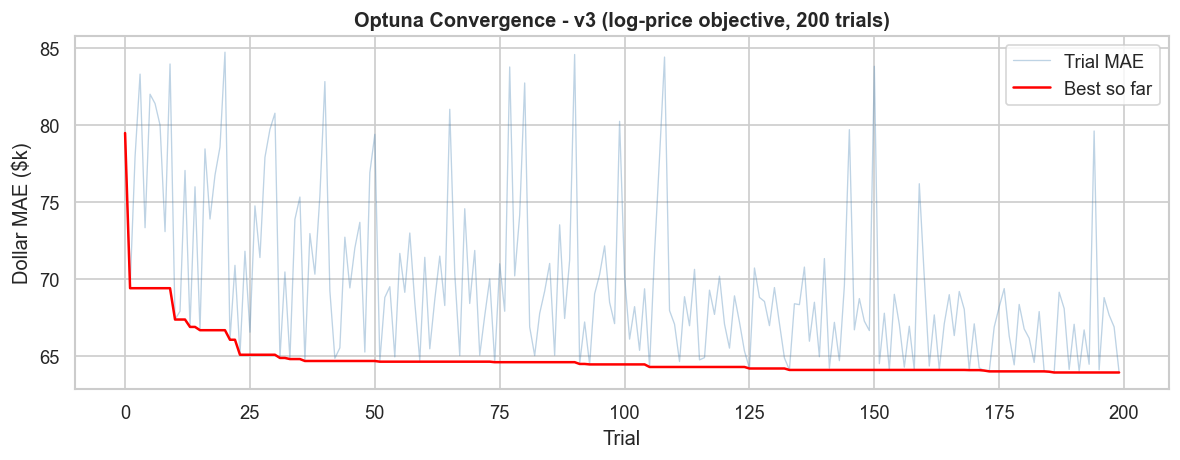

In [ ]:
# ---------------------------------------------------------------------------
# Optuna hyperparameter tuning - LightGBM on filtered TRAIN set (v3)
# v3 changes:
#   - Objective trains on log(price), evaluates dollar MAE via exp() transform
#   - Dollar MAE directly comparable to v2 baseline (~$48k)
# ---------------------------------------------------------------------------


def optuna_objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators',      400,  2500),
        'max_depth':         trial.suggest_int('max_depth',          3,    8),
        'num_leaves':        trial.suggest_int('num_leaves',         15,   127),
        'learning_rate':     trial.suggest_float('learning_rate',    0.003, 0.12, log=True),
        'subsample':         trial.suggest_float('subsample',        0.6,  1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5,  1.0),
        'min_child_samples': trial.suggest_int('min_child_samples',  5,    80),
        'reg_alpha':         trial.suggest_float('reg_alpha',        1e-4, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda',       1e-4, 10.0, log=True),
        'min_split_gain':    trial.suggest_float('min_split_gain',   0.0,  5.0),
        'random_state': SEED, 'n_jobs': -1, 'verbose': -1,
    }
    model = LGBMRegressor(**params)
    # Train on log(price), evaluate in dollar MAE for interpretability
    log_preds = cross_val_predict(
        model, X_train_f, y_train_f_log, cv=kf, n_jobs=-1,
    )
    dollar_mae = mean_absolute_error(np.exp(y_train_f_log), np.exp(log_preds))
    return dollar_mae


study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
)
log.info('Running Optuna - 200 trials on filtered training set (v3 log-price)...')
study.optimize(optuna_objective, n_trials=200, show_progress_bar=True)

best_params = {**study.best_params, 'random_state': SEED, 'n_jobs': -1, 'verbose': -1}
print(f'Best CV dollar MAE (log-price model): ${study.best_value:,.0f}')
print(f'  (v2 baseline: ~$48,000; improvement from log-price + expanded data expected)')
print('\nTuned parameters:')
for k, v in best_params.items():
    print(f'  {k}: {v}')

trials_df = study.trials_dataframe()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(trials_df['number'], trials_df['value'] / 1000,
        alpha=0.35, color='steelblue', lw=0.8, label='Trial MAE')
ax.plot(trials_df['number'], trials_df['value'].cummin() / 1000,
        color='red', lw=1.5, label='Best so far')
ax.set_xlabel('Trial')
ax.set_ylabel('Dollar MAE ($k)')
ax.set_title('Optuna Convergence - v3 (log-price objective, 200 trials)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('plots/optuna_convergence_v3.png', dpi=150, bbox_inches='tight')
plt.show()


In [6]:
# ---------------------------------------------------------------------------
# Fit best models on full TRAINING set, evaluate on HELD-OUT test (v3)
# v3 changes:
#   - Point model trained on log(price); predictions exp()-ed back to dollars
#   - Quantile models (p=0.10, p=0.90) also on log(price) for proportional PI
#   - Per-predicted-quintile residual sigma stored for segment-aware intervals
#   - Price range extended to $1.25M; 1,276 more training observations
# ---------------------------------------------------------------------------
from sklearn.linear_model import LinearRegression as LR

# --- Filtered model (tuned LightGBM on log-price) ------------------------
best_lgbm_f = LGBMRegressor(**best_params)
best_lgbm_f.fit(X_train_f, y_train_f_log)

# Evaluate in dollar space (exp back)
y_pred_log_test_f = best_lgbm_f.predict(X_test_f)
y_pred_test_f     = np.exp(y_pred_log_test_f)
test_r2_f   = r2_score(y_test_f, y_pred_test_f)
test_mae_f  = mean_absolute_error(y_test_f, y_pred_test_f)
test_rmse_f = np.sqrt(mean_squared_error(y_test_f, y_pred_test_f))

print('=' * 60)
print('FILTERED MODEL v3 - HELD-OUT TEST SET')
print('=' * 60)
print(f'  R2:   {test_r2_f:.4f}  (v2 baseline: 0.7230)')
print(f'  MAE:  ${test_mae_f:,.0f}  (v2 baseline: $48,471)')
print(f'  RMSE: ${test_rmse_f:,.0f}')

# --- Quantile models on log-price ----------------------------------------
# Training on log(price) means interval width is proportional to price level.
# exp(q10.predict(X)) is the exact 10th percentile of price (exp is monotone).
q_params = {k: v for k, v in best_params.items()}
q_params.update({'objective': 'quantile',
                 'n_estimators': min(best_params.get('n_estimators', 1500), 2000)})

print('\nFitting quantile models (p=0.10, p=0.90) on log-price...')
q10 = LGBMRegressor(**{**q_params, 'alpha': 0.10})
q90 = LGBMRegressor(**{**q_params, 'alpha': 0.90})
q10.fit(X_train_f, y_train_f_log)
q90.fit(X_train_f, y_train_f_log)

lo_pred  = np.exp(q10.predict(X_test_f))
hi_pred  = np.exp(q90.predict(X_test_f))
coverage = np.mean((y_test_f >= lo_pred) & (y_test_f <= hi_pred))
avg_wid  = np.mean(hi_pred - lo_pred)
print(f'  80% PI coverage: {coverage:.1%}  (target: 80.0%)')
print(f'  Average PI width: ${avg_wid:,.0f}')

# Coverage by price band
test_df_cov = pd.DataFrame({
    'actual': y_test_f.values, 'lo': lo_pred, 'hi': hi_pred,
})
bins_cov   = [0, 400_000, 500_000, 600_000, 700_000, 900_000, 9_999_999]
labels_cov = ['<400k','400-500k','500-600k','600-700k','700-900k','900k+']
test_df_cov['band'] = pd.cut(test_df_cov['actual'], bins=bins_cov, labels=labels_cov)
test_df_cov['covered'] = (test_df_cov['actual'] >= test_df_cov['lo']) & \
                          (test_df_cov['actual'] <= test_df_cov['hi'])
cov_by_band = test_df_cov.groupby('band', observed=True)['covered'].agg(['mean','count'])
print('\n  Coverage by price band:')
for band, row in cov_by_band.iterrows():
    print(f'    {band:<12} n={int(row["count"]):>4}  coverage={row["mean"]:.1%}')

# --- Refit on ALL filtered data for production ---------------------------
best_lgbm_f_prod = LGBMRegressor(**best_params)
best_lgbm_f_prod.fit(X_full_f, y_full_f_log)

q10_prod = LGBMRegressor(**{**q_params, 'alpha': 0.10})
q90_prod = LGBMRegressor(**{**q_params, 'alpha': 0.90})
q10_prod.fit(X_full_f, y_full_f_log)
q90_prod.fit(X_full_f, y_full_f_log)

# CV predictions for unbiased residual diagnostics
cv_log_preds_f = cross_val_predict(
    best_lgbm_f_prod, X_full_f, y_full_f_log, cv=kf, n_jobs=-1
)
cv_preds_f     = np.exp(cv_log_preds_f)   # dollar predictions
cv_residuals   = y_full_f.values - cv_preds_f
residual_std_f  = np.std(cv_residuals)
residual_mean_f = np.mean(cv_residuals)

# --- Per-predicted-quintile residual sigma --------------------------------
# Captures heteroscedasticity that survives the log transform.
# Stored as 5 break points + 5 sigma values for dashboard segment-aware intervals.
pred_df_cv = pd.DataFrame({'pred': cv_preds_f, 'resid': cv_residuals})
pred_df_cv['q5'] = pd.qcut(pred_df_cv['pred'], 5, labels=False)
quintile_sigma  = pred_df_cv.groupby('q5')['resid'].std().values.tolist()
quintile_breaks = [float(pred_df_cv[pred_df_cv['q5'] == i]['pred'].max())
                   for i in range(4)]  # 4 breaks defining 5 buckets

print(f'\n  Global CV residual sigma: ${residual_std_f:,.0f}')
print(f'  Per-quintile sigma (Q1->Q5):')
for i, (brk, sig) in enumerate(zip(['<' + str(round(quintile_breaks[0]/1000)) + 'k'
    if i == 0 else str(round(quintile_breaks[i-1]/1000)) + '-' + str(round(quintile_breaks[i]/1000)) + 'k'
    for i in range(4)] + [str(round(quintile_breaks[-1]/1000)) + 'k+'],
    quintile_sigma)):
    print(f'    {brk:<14} sigma=${sig:,.0f}')

# --- Appreciation: residualized regression --------------------------------
_feats_no_time = [f for f in feature_cols_f if f != 'months_since_base']
_X_no_time = X_full_f[_feats_no_time].fillna(X_full_f[_feats_no_time].median())
_ridge_no_time = Ridge(alpha=10).fit(_X_no_time, y_full_f)
_resid_no_time = y_full_f.values - _ridge_no_time.predict(_X_no_time)
_lr_time = LR().fit(X_full_f[['months_since_base']], _resid_no_time)
monthly_appreciation   = _lr_time.coef_[0]
annual_appreciation_pct = (monthly_appreciation * 12) / y_full_f.median() * 100

print(f'  Monthly trend (residualized): ${monthly_appreciation:,.0f}/mo  '
      f'(~{annual_appreciation_pct:.1f}% annualised)')

# --- Feature importance --------------------------------------------------
imp = pd.Series(best_lgbm_f_prod.feature_importances_, index=feature_cols_f)\
         .sort_values(ascending=False)
print('\nTop 15 features (split-based importance):')
for nm, v in imp.head(15).items():
    print(f'  {nm:<32} {v:>5.0f}')

# --- Save filtered model (v3) --------------------------------------------
joblib.dump({
    'model':                  best_lgbm_f_prod,
    'quantile_lo':            q10_prod,
    'quantile_hi':            q90_prod,
    'feature_cols':           feature_cols_f,
    'residual_std':           residual_std_f,
    'residual_mean':          residual_mean_f,
    'monthly_appreciation':   monthly_appreciation,
    'annual_appreciation_pct': annual_appreciation_pct,
    'test_r2':  test_r2_f,
    'test_mae': test_mae_f,
    'quantile_coverage':  coverage,
    'quantile_avg_width': avg_wid,
    'lat_mean': LAT_MEAN,
    'lon_mean': LON_MEAN,
    'lot_99':   LOT_99,
    'best_params': best_params,
    'seed': SEED,
    'feature_version': 3,
    'log_target': True,          # v3: model predicts log(price); exp() at inference
    'price_min': FILTER_PRICE_MIN,
    'price_max': FILTER_PRICE_MAX,
    'quintile_breaks': quintile_breaks,  # 4 breaks for 5 price quintiles
    'quintile_sigma':  quintile_sigma,   # per-quintile dollar residual sigma
}, FILTERED_MODEL_FILE)
log.info(f'Saved -> {FILTERED_MODEL_FILE}')

# Save results CSV (store dollar-space CV predictions + quantile bounds)
res_f = model_df_f[[c for c in META_COLS if c in model_df_f.columns] + [TARGET]].copy()
res_f['predicted']    = np.exp(best_lgbm_f_prod.predict(X_full_f))
res_f['residual']     = res_f[TARGET] - res_f['predicted']
res_f['pct_error']    = res_f['residual'] / res_f[TARGET] * 100
res_f['cv_predicted'] = cv_preds_f
res_f['pred_q10']     = np.exp(q10_prod.predict(X_full_f))
res_f['pred_q90']     = np.exp(q90_prod.predict(X_full_f))
res_f.to_csv(FILTERED_RESULTS_CSV, index=False)

# --- Full model (unchanged — kept for reference) -------------------------
best_lgbm = LGBMRegressor(**best_params)
best_lgbm.fit(X_train, y_train)
y_pred_test = best_lgbm.predict(X_test)

print(f'\n{"=" * 55}')
print('FULL MODEL - HELD-OUT TEST SET')
print('=' * 55)
print(f'  R2:   {r2_score(y_test, y_pred_test):.4f}')
print(f'  MAE:  ${mean_absolute_error(y_test, y_pred_test):,.0f}')
print(f'  RMSE: ${np.sqrt(mean_squared_error(y_test, y_pred_test)):,.0f}')

best_lgbm_prod = LGBMRegressor(**best_params)
best_lgbm_prod.fit(X_full, y_full)
cv_preds_full  = cross_val_predict(best_lgbm_prod, X_full, y_full, cv=kf, n_jobs=-1)
residual_std   = np.std(y_full.values - cv_preds_full)

joblib.dump({
    'model':        best_lgbm_prod,
    'feature_cols': feature_cols,
    'residual_std': residual_std,
    'test_r2':  r2_score(y_test, y_pred_test),
    'test_mae': mean_absolute_error(y_test, y_pred_test),
    'lat_mean': LAT_MEAN,
    'lon_mean': LON_MEAN,
    'lot_99':   LOT_99,
    'seed': SEED,
    'feature_version': 3,
}, MODEL_FILE)
log.info(f'Saved -> {MODEL_FILE}')

res = model_df[[c for c in META_COLS if c in model_df.columns] + [TARGET]].copy()
res['predicted']    = best_lgbm_prod.predict(X_full)
res['residual']     = res[TARGET] - res['predicted']
res['pct_error']    = res['residual'] / res[TARGET] * 100
res['cv_predicted'] = cv_preds_full
res.to_csv(RESULTS_CSV, index=False)

print(f'\nAll artefacts saved to models/ and data/.')
print(f'feature_version=3, log_target=True')


FILTERED MODEL v3 - HELD-OUT TEST SET
  R2:   0.8244  (v2 baseline: 0.7230)
  MAE:  $62,469  (v2 baseline: $48,471)
  RMSE: $87,207

Fitting quantile models (p=0.10, p=0.90) on log-price...
  80% PI coverage: 69.6%  (target: 80.0%)
  Average PI width: $164,001

  Coverage by price band:
    <400k        n= 251  coverage=50.2%
    400-500k     n= 314  coverage=83.8%
    500-600k     n= 213  coverage=75.6%
    600-700k     n= 164  coverage=70.7%
    700-900k     n= 202  coverage=73.3%
    900k+        n= 125  coverage=55.2%


2026-04-09 19:23:07,471 INFO Saved -> models/hedonic_model_filtered.joblib



  Global CV residual sigma: $88,512
  Per-quintile sigma (Q1->Q5):
    <418k          sigma=$42,703
    418-495k       sigma=$63,933
    495-586k       sigma=$85,532
    586-745k       sigma=$104,546
    745k+          sigma=$122,472
  Monthly trend (residualized): $-151/mo  (~-0.3% annualised)

Top 15 features (split-based importance):
  home_age                          3371
  lat_sq                            3052
  lat_lon_x                         2691
  lot_capped                        2546
  sqft_per_lot_capped               2520
  lon_sq                            2328
  SQUARE_FEET                       2304
  bath_per_sqft                     2248
  lat_c                             2225
  sqft_per_bed                      2218
  lon_c                             2193
  months_since_base                 2098
  income_sqft_idx                   1689
  log_home_age                      1577
  median_home_value                 1333

FULL MODEL - HELD-OUT TEST SET
  R2:   0.869

2026-04-09 19:23:54,081 INFO Saved -> models/hedonic_model.joblib



All artefacts saved to models/ and data/.
feature_version=3, log_target=True


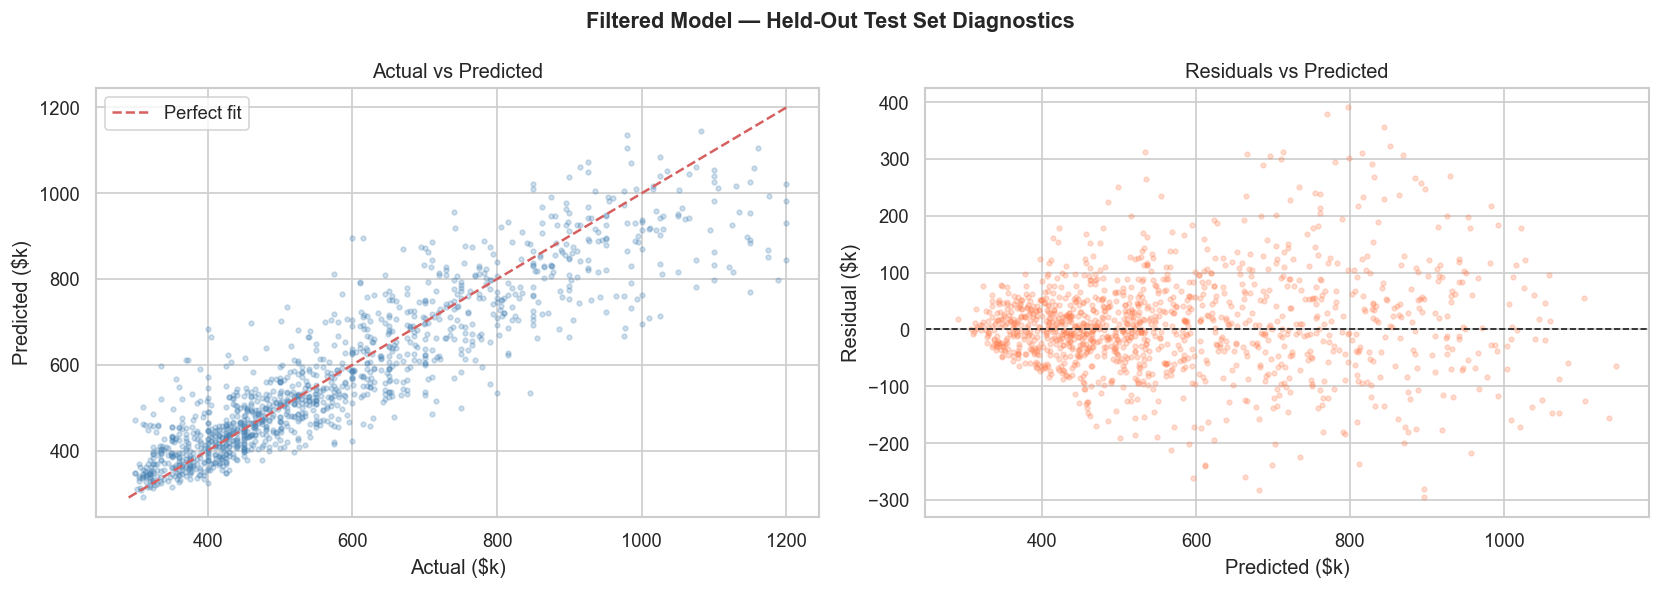

See 03_evaluation.ipynb for full evaluation, geographic analysis, and offer logic.


In [7]:
# ---------------------------------------------------------------------------
# Quick diagnostic — filtered model
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Filtered Model — Held-Out Test Set Diagnostics", fontsize=13, fontweight="bold")

axes[0].scatter(y_test_f / 1e3, y_pred_test_f / 1e3, alpha=0.25, s=8, c="steelblue")
lims = [min(y_test_f.min(), y_pred_test_f.min()) / 1e3,
        max(y_test_f.max(), y_pred_test_f.max()) / 1e3]
axes[0].plot(lims, lims, "r--", lw=1.5, label="Perfect fit")
axes[0].set_xlabel("Actual ($k)")
axes[0].set_ylabel("Predicted ($k)")
axes[0].set_title("Actual vs Predicted")
axes[0].legend()

resid_test = y_test_f.values - y_pred_test_f
axes[1].scatter(y_pred_test_f / 1e3, resid_test / 1e3, alpha=0.25, s=8, c="coral")
axes[1].axhline(0, color="k", ls="--", lw=1)
axes[1].set_xlabel("Predicted ($k)")
axes[1].set_ylabel("Residual ($k)")
axes[1].set_title("Residuals vs Predicted")

plt.tight_layout()
plt.savefig("plots/filtered_model_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

print("See 03_evaluation.ipynb for full evaluation, geographic analysis, and offer logic.")